In [2]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sb
import csv
from scipy import stats
from scipy.spatial.distance import cosine
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [3]:
post_info = pd.read_csv("participant_content.csv")
list(post_info.columns)

['sessionId',
 'treatmentArm',
 'participantCode',
 'profilePicture',
 'firstName',
 'lastName',
 'bio',
 'postOrCommentId',
 'userContent',
 'staticContent',
 'dynamicContent',
 'postOrCommentText',
 'postOrCommentDate',
 'postLikes',
 'postDislikes',
 'participantLiked',
 'participantDisliked',
 'parentPost',
 'previousCommentOrPost',
 'dwellTimeInSeconds']

In [4]:
stops = stopwords.words('english')
tknzr = TweetTokenizer()
vader = SentimentIntensityAnalyzer()
# vader.polarity_scores(sentence)

# GloVe Setup

In [5]:
#A helper function that turns GloVe files into a dictionary

def get_glove(filename):
    with open(filename, 'r', encoding='utf8') as f:
        reader = csv.reader(f, delimiter=' ', quoting=csv.QUOTE_NONE)
        return {line[0]: np.array(list(map(float, line[1: ])), dtype=float) for line in reader}

In [6]:
glove = get_glove('../CL for ACT/glove.840B.300d.txt')

In [7]:
def get_panas_dists(w, m=glove, short=False):
    
    positive_w = ['interested', 'excited', 'strong', 'enthusiastic', 'proud', 'alert', 'inspired', 'determined', 'attentive', 'active']
    
    if short:
        positive_w = ['alert', 'inspired', 'determined', 'attentive', 'active']
        
    positive_dists = [cosine(m[w], m[w_]) for w_ in positive_w]
    
    negative_w = ['distressed', 'upset', 'guilty', 'scared', 'hostile', 'irritable', 'ashamed', 'nervous', 'jittery', 'afraid']
    
    if short:
        negative_w = ['upset', 'hostile', 'ashamed', 'nervous', 'afraid']
    negative_dists = [cosine(m[w], m[w_]) for w_ in negative_w]

    return {'positive': 1 - np.mean(positive_dists),
            'negative': 1 - np.mean(negative_dists),
            'panas': 1 - np.mean(negative_dists) - 1 - np.mean(positive_dists)}

def panas_we(s, short=False, stops=stops):
    r = [get_panas_dists(w, short=short) for w in tknzr.tokenize(s.lower()) if w not in stops and w in glove]
    if len(r) != 0:
        return {'positive': np.mean([i['positive'] for i in r]),
                'negative': np.mean([i['negative'] for i in r]),
                'panas': np.mean([i['panas'] for i in r])}
    else:
        return {'positive': np.nan,
                'negative': np.nan,
                'panas': np.nan}
    

    

# Emoji Setup

In [8]:
grams = Counter()
for t in post_info[post_info.userContent == 1].postOrCommentText:
    grams.update(list(t))

sorted(grams.items(), key=lambda x: x[1], reverse=True)[75:]

[('👍', 16),
 ('💯', 15),
 ('8', 14),
 ('9', 14),
 ('4', 14),
 ('7', 12),
 ('_', 11),
 ('#', 9),
 ('️', 7),
 ('💀', 7),
 ('@', 5),
 ('🏼', 5),
 ('🤷', 5),
 ('👏', 5),
 ('6', 5),
 ('&', 4),
 ('+', 4),
 ('✨', 4),
 ('\u200d', 3),
 ('—', 3),
 ('😊', 3),
 ('X', 3),
 ('Z', 3),
 ('🤔', 3),
 ('👌', 3),
 ('🔥', 2),
 ('🏻', 2),
 ('♀', 2),
 ('🙌', 2),
 ('😆', 2),
 ('$', 2),
 ('🎄', 2),
 ('❤', 2),
 ('🖤', 2),
 ('‘', 2),
 ('😁', 2),
 ('🇺', 2),
 ('🇸', 2),
 ('\U0001fae1', 1),
 ('🎉', 1),
 ('🐼', 1),
 ('😬', 1),
 ('é', 1),
 ('🥴', 1),
 ('🧠', 1),
 ('💋', 1),
 ('💅', 1),
 ('🍬', 1),
 ('🍭', 1),
 ('🏩', 1),
 ('🛍', 1),
 ('🎀', 1),
 ('💃', 1),
 ('☺', 1),
 ('🤍', 1),
 ('👪', 1),
 ('Q', 1),
 ('👀', 1),
 ('😭', 1),
 ('👋', 1),
 ('🎁', 1),
 ('😔', 1),
 ('\U0001fae3', 1),
 ('😕', 1),
 ('🙋', 1),
 ('😢', 1),
 ('😂', 1),
 ('🙂', 1),
 ('🥂', 1),
 ('🤞', 1),
 ('🙃', 1),
 ('🥁', 1),
 ('🥳', 1),
 ('😅', 1),
 ('✌', 1),
 ('🍅', 1),
 ('📚', 1),
 ('🌎', 1),
 ('🌐', 1),
 ('🌍', 1),
 ('🤝', 1)]

In [9]:
emojis = '👍💯💀🤷👏✨😊🤔👌🔥🙌😆🎄❤🖤😁🎉🐼😬🥴🧠💋💅🍬🍭🏩🛍🎀💃☺🤍👪👀😭👋🎁😔😕🙋😢😂🙂🥂🤞🙃🥁🥳😅✌🍅📚🌎🌐🌍🤝'

for ind, r in post_info[post_info.userContent == 1].iterrows():
    t = r.postOrCommentText
    if any([e in t for e in emojis]):
        ot = None
        if pd.notnull(r.parentPost):
            print("Check: {}".format(r.parentPost))
            ot = post_info[post_info.postOrCommentId == r.parentPost].postOrCommentText.values[0]
        print(ot, ' ::: ', t)
        print('------------------------------------------------------')
        

Check: 655d0ae8f1c1b5001f5cb3c1
Automatic rifles need to be illegal.  :::  💯
------------------------------------------------------
Check: 654eb751ae0ef3001e0a8619
🚨🚨🚨BONUS PAYMENT ALERT🚨🚨🚨

Thanks for helping to test this social media platform 🙌😇🙌

Remember and correctly enter this secret passcode during the survey at the end of the study to receive a bonus payment of $1 😲🤩💯🤐

Note that THIS CODE IS NOT YOUR STUDY COMPLETION CODE

🥳 🤑 💸💰 🥳  

Your super secret passcode: WIN

🥳 🤑 💸💰 🥳   :::  WHEW 🔥
------------------------------------------------------
Check: 654eb741ae0ef3001e0a860e
🚨🚨🚨BONUS PAYMENT ALERT🚨🚨🚨

Thanks for helping to test this social media platform 🙌😇🙌

Remember and correctly enter this secret passcode during the survey at the end of the study to receive a bonus payment of $1 😲🤩💯🤐

Note that THIS CODE IS NOT YOUR STUDY COMPLETION CODE

🥳 🤑 💸💰 🥳  

Your super secret passcode: WIN

🥳 🤑 💸💰 🥳   :::  🎉
------------------------------------------------------
None  :::  Big fan 

In [10]:
emojis = ''.join(list(set(list(emojis))))

In [11]:
from bs4 import BeautifulSoup
import pandas as pd

# Open the HTML file
with open('Emoji Sentiment Ranking v1.0.html', 'r', encoding='utf-8') as file:
    html_content = file.read()

# Parse the HTML content
soup = BeautifulSoup(html_content, 'html.parser')

# Find the table element
table = soup.find('table', {'id': 'myTable'})

# Extract the table headers
headers = []
header_row = table.find('tr')
for th in header_row.find_all('th'):
    headers.append(th.text.strip())

# Extract the table data
data = []
table_rows = table.find_all('tr')[1:]  # Skip the header row

for row in table_rows:
    row_data = []
    row_cells = row.find_all('td')
    for cell in row_cells:
        row_data.append(cell.text.strip())
    data.append(row_data)

# Create the DataFrame
emoji_df = pd.DataFrame(data, columns=headers)

# Clean the dataframe
emoji_df = emoji_df[['Char','Neg[0...1]','Neut[0...1]','Pos[0...1]','Sentiment score[-1...+1]']]
emoji_df.columns = ['emoji','neg','neu','pos','sent']
emoji_df

,emoji,neg,neu,pos,sent
0,😂,0.247,0.285,0.468,0.221
1,❤,0.044,0.166,0.790,0.746
2,♥,0.035,0.272,0.693,0.657
3,😍,0.052,0.219,0.729,0.678
4,😭,0.436,0.220,0.343,-0.093
...,...,...,...,...,...
746,♮,0.125,0.625,0.250,0.125
747,🅾,0.375,0.375,0.250,-0.125
748,🔄,0.125,0.750,0.125,0.000
749,☄,0.125,0.750,0.125,0.000


In [12]:
emoji_df.index = emoji_df.emoji
emoji_dict = emoji_df.to_dict('index')
emoji_dict

{'😂': {'emoji': '😂',
  'neg': '0.247',
  'neu': '0.285',
  'pos': '0.468',
  'sent': '0.221'},
 '❤': {'emoji': '❤',
  'neg': '0.044',
  'neu': '0.166',
  'pos': '0.790',
  'sent': '0.746'},
 '♥': {'emoji': '♥',
  'neg': '0.035',
  'neu': '0.272',
  'pos': '0.693',
  'sent': '0.657'},
 '😍': {'emoji': '😍',
  'neg': '0.052',
  'neu': '0.219',
  'pos': '0.729',
  'sent': '0.678'},
 '😭': {'emoji': '😭',
  'neg': '0.436',
  'neu': '0.220',
  'pos': '0.343',
  'sent': '-0.093'},
 '😘': {'emoji': '😘',
  'neg': '0.053',
  'neu': '0.193',
  'pos': '0.754',
  'sent': '0.701'},
 '😊': {'emoji': '😊',
  'neg': '0.060',
  'neu': '0.237',
  'pos': '0.704',
  'sent': '0.644'},
 '👌': {'emoji': '👌',
  'neg': '0.094',
  'neu': '0.249',
  'pos': '0.657',
  'sent': '0.563'},
 '💕': {'emoji': '💕',
  'neg': '0.042',
  'neu': '0.285',
  'pos': '0.674',
  'sent': '0.632'},
 '👏': {'emoji': '👏',
  'neg': '0.104',
  'neu': '0.271',
  'pos': '0.624',
  'sent': '0.520'},
 '😁': {'emoji': '😁',
  'neg': '0.127',
  'neu': '

In [13]:
def emoji_sent(s):
    sents = [emoji_dict[w] for w in list(set(s)) if w in emoji_dict]
    
    if len(sents) == 0:
        return {'pos': np.nan,
                'neg': np.nan,
                'sent': np.nan}
    else:
        return {'pos': np.mean([float(d['pos']) for d in sents]),
                'neg': np.mean([float(d['neg']) for d in sents]),
                'sent': np.mean([float(d['sent']) for d in sents])}

In [14]:
emoji_sent("💙💜✨")

{'pos': 0.6216666666666666,
 'neg': 0.043333333333333335,
 'sent': 0.5783333333333333}

In [15]:
emoji_sent("💙💙💙 💜✨")

{'pos': 0.6216666666666666,
 'neg': 0.043333333333333335,
 'sent': 0.5783333333333333}

In [16]:
emoji_sent("😒😔💀😑")

{'pos': 0.24949999999999997, 'neg': 0.509, 'sent': -0.25949999999999995}

In [17]:
sorted([(e, grams[e]) for e in emojis if e not in emoji_dict], key=lambda x: x[1], reverse=True)

[('🤷', 5),
 ('🤔', 3),
 ('🖤', 2),
 ('🛍', 1),
 ('🌐', 1),
 ('🤍', 1),
 ('🤞', 1),
 ('🥳', 1),
 ('🤝', 1),
 ('🥂', 1),
 ('🧠', 1),
 ('🥁', 1),
 ('🙃', 1),
 ('🥴', 1),
 ('🙂', 1)]

In [18]:
sorted([(e, float(emoji_dict[e]['sent'])) for e in emojis if e in emoji_dict], key=lambda x: x[1], reverse=True)

[('🎁', 0.759),
 ('❤', 0.746),
 ('🎉', 0.738),
 ('💃', 0.734),
 ('💋', 0.691),
 ('☺', 0.657),
 ('😊', 0.644),
 ('🎀', 0.629),
 ('🌍', 0.592),
 ('👌', 0.563),
 ('🙌', 0.559),
 ('🎄', 0.531),
 ('👍', 0.521),
 ('👏', 0.52),
 ('🙋', 0.485),
 ('✌', 0.463),
 ('😁', 0.449),
 ('🏩', 0.421),
 ('👋', 0.413),
 ('😆', 0.409),
 ('💅', 0.388),
 ('🍬', 0.364),
 ('✨', 0.351),
 ('🍅', 0.35),
 ('📚', 0.336),
 ('🌎', 0.319),
 ('🍭', 0.3),
 ('🐼', 0.261),
 ('😂', 0.221),
 ('😬', 0.194),
 ('😅', 0.178),
 ('🔥', 0.139),
 ('💯', 0.12),
 ('👀', 0.063),
 ('😢', 0.007),
 ('👪', -0.017),
 ('😭', -0.093),
 ('😔', -0.146),
 ('💀', -0.207),
 ('😕', -0.397)]

In [19]:
emoji_dict

{'😂': {'emoji': '😂',
  'neg': '0.247',
  'neu': '0.285',
  'pos': '0.468',
  'sent': '0.221'},
 '❤': {'emoji': '❤',
  'neg': '0.044',
  'neu': '0.166',
  'pos': '0.790',
  'sent': '0.746'},
 '♥': {'emoji': '♥',
  'neg': '0.035',
  'neu': '0.272',
  'pos': '0.693',
  'sent': '0.657'},
 '😍': {'emoji': '😍',
  'neg': '0.052',
  'neu': '0.219',
  'pos': '0.729',
  'sent': '0.678'},
 '😭': {'emoji': '😭',
  'neg': '0.436',
  'neu': '0.220',
  'pos': '0.343',
  'sent': '-0.093'},
 '😘': {'emoji': '😘',
  'neg': '0.053',
  'neu': '0.193',
  'pos': '0.754',
  'sent': '0.701'},
 '😊': {'emoji': '😊',
  'neg': '0.060',
  'neu': '0.237',
  'pos': '0.704',
  'sent': '0.644'},
 '👌': {'emoji': '👌',
  'neg': '0.094',
  'neu': '0.249',
  'pos': '0.657',
  'sent': '0.563'},
 '💕': {'emoji': '💕',
  'neg': '0.042',
  'neu': '0.285',
  'pos': '0.674',
  'sent': '0.632'},
 '👏': {'emoji': '👏',
  'neg': '0.104',
  'neu': '0.271',
  'pos': '0.624',
  'sent': '0.520'},
 '😁': {'emoji': '😁',
  'neg': '0.127',
  'neu': '

In [20]:
grams['🙂']

1

# IH Post Setup

In [21]:
ih_posts = ["A lot of reporting I've seen suggests that the illegal crossing are very dangerous. If that's true, we should do everything we can to deter this. I've heard that many die every year crossing in unsafe areas, and that even when they make it across they die of heat and thrust or crammed in the back of trucks. It seems like, then, a border wall is for their safety as well as ours.",
            "I get the reason some people want gun control.  I want them to understand that where I live, we need guns. We are over run with coyotes. They kill our pets. We try and kill them. You have to use a weapon with range. What youd call an assault weapon is perfect for that, and they are popular here for coyotes. I just scare them with my gun, because I don't ever hit them",
            "I might be wrong but it seems like the places that have the most mayhem are those with the most restrictive laws. I think about the pressure cooker bombs a few years back at the marathon.",
            "I totally understand, it's not the guns fault. We shouldn't do away with guns because of recent incidents, but it seems to me that we need to look at those who use the guns. I think regulating who can get access to them could help solve this issue. I agree that people have the need to feel safe and they should secure their environment the way they feel comfortable",
            "I try not to be naive that utopia exists or can exist. I know some people think differently, but I do believe in laws and rules and that people are basically good and follow them most of the time. I'd love to see data on this, but I feel like it's only the fringe that does not follow them and causes mayhem for the rest of us.",
            "I understand it is a complex issue and I actually have no problem with asylum seekers. I personally believe that we should be letting in people who will come in to this country the legal way and assimilate into our country. This is just my perspective and open to hear the views of others.",
            "I understand why people are worried about the Southern Border situation, but I don't think that has much to do with terrorism. I might be wrong, but I think that more terrorists are coming over the Canadian border.",
            "I understand why some people want  gun control.  It would help insure guns aren't  given to unstable people. But I also believe that as an American I have every right to defend my property, family, and myself with a gun or guns. I worry only criminals would have weapons.",
            "I'm honestly curious about what the other side thinks. I agree that the gangs and the drugs that come over here from Mexico are a problem. At the same time,  I think we already have gangs and drugs over here before Mexico brought them over.",
            "I'm no psychologist, but I don't think that criminals care what the laws are and what they can or can't do. If that is true, they will obtain a gun by whatever means they can, carry it illegally, use it in a crime and possibly use it to rob you.",
            "I'm not an expert on gun policy, but I did write research papers on the topic in college. While doing research, I was persuaded there was a lot misinformation put out by the NRA, which wa led by someone personally enriching himself from the sales of ammunition.",
            "I'm open to hearing other views, but it sure seems like gun control doesn't work. I've heard that the states with the strictest gun control has the highest crime rates and murder rates. I would think that's because only criminal have the guns.",
            "I'm sure others disagree, but I don't think it's our responsibility as a nation to take care of people from other countries who can't get any help from their own government. I think we have enough AMERICANS who need assistance, and we should help them first. I guess I just don't understand why we should be paying for anyone who manages to sneak in to our country.",
            "It's been a long time since I took US history, but I believe this land as far as Texas, New Mexico, Arizona, California, we're all Mexico territory before The United States took it from them. So I guess it would make sense that They're going to come back, maybe because they never left.",
            "Living close to the border has made me think that we need a wall. Our border patrol, who are the real experts, has asked for a wall. I haven't dug into the numbers, but I've heard the wall has already made in a difference in the areas it is in place. I feel we shouldn't ask our border patrol to risk their lives and not give them the tools they ask for.",
            "Others might disagree, but I don't understand the argument that  Mexicans are taking jobs.  If you are unemployed, couldn't find a job anywhere, and a lettuce field in your city that was hiring, would you apply? My sense is that most Americans would say no.",
            "Others might disagree, but I think we need reasonable and uniform NATIONAL gun legislation. I think one reason for the failure of gun control laws in the US is the pathwork of state-to-state differences. I might be wrong, but I think Congress even forbid the government trackingof gun violence deaths.",
            "I'm not an expert, but it seems like more immigration can only hurt me. I'm interesting in hearing the argument for the other side.",
            "I understand the argument that the system needs reform. However, my own view is that many who have immigrated are the epitome of an outstanding citizens that contributes to society and our economy.",
            "I'm open to other ideas, but I wonder if we should require every gun sale to be registered and require gun manufacturers to include trigger locks at no additional charge to the consumer.  It probably won't solve all our problems, but I think that we can take measures to reduce gun deaths without trampling on the 2nd Amendment."]



In [22]:
ih = []

for p in ih_posts:
    ids = list(post_info[post_info.postOrCommentText.apply(lambda x: x == p)].postOrCommentId)
    if len(ids) == 0:
        print(p)
    ih += ids

ih

['654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb59c',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb59c',
 '654e2eccf18dbd001f7ab0a8',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb59c',
 '655d0ae8f1c1b5001f5cb59c',
 '655d0ae8f1c1b5001f5cb59c',
 '655d0ae8f1c1b5001f5cb59c',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '654e2eccf18dbd001f7ab0a8',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb59c',
 '654e2eccf18dbd001f7ab0a8',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb55f',
 '655d0ae8f1c1b5001f5cb55f',
 '655d0ae8f1c1b5001f5cb59c',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '655d0ae8f1c1b5001f5cb59c',
 '655d0ae8f1c1b5001f5cb55f',
 '654e2eccf18dbd001f7ab0a8',
 '654e2eccf18d

# Lib/Con Post Setup

In [23]:
lib_posts = [
"I understand why people are worried about the Southern Border situation, but I don't think that has much to do with terrorism. I might be wrong, but I think that more terrorists are coming over the Canadian border.",
"Others might disagree, but I don't understand the argument that  Mexicans are taking jobs.  If you are unemployed, couldn't find a job anywhere, and a lettuce field in your city that was hiring, would you apply? My sense is that most Americans would say no.",
"It's been a long time since I took US history, but I believe this land as far as Texas, New Mexico, Arizona, California, we're all Mexico territory before The United States took it from them. So I guess it would make sense that They're going to come back, maybe because they never left.",
"Others might disagree, but I think we need reasonable and uniform NATIONAL gun legislation. I think one reason for the failure of gun control laws in the US is the pathwork of state-to-state differences. I might be wrong, but I think Congress even forbid the government trackingof gun violence deaths.",
"I'm open to other ideas, but I wonder if we should require every gun sale to be registered and require gun manufacturers to include trigger locks at no additional charge to the consumer.  It probably won't solve all our problems, but I think that we can take measures to reduce gun deaths without trampling on the 2nd Amendment.",
"The problem is not guns; it's the people who have them. I know lots of people that I'd be comfortable having any type of gun. We need to restrict gun possession to responsible people - not drunks, or wife-beaters, not white supremesists. And not political extremeidts. Pretty obvious.",
"Background checks will stop some people who should not own guns from owning them and that's a start. We have finance laws we know people will break but we still do what we can to try to police it.",
"We need mandatory training, licensing, and spaces where guns are and are not allowed.",
"We live in a society and pay taxes and agree to social norms for protection. We do not live in the world as independent, armed encampments. It may cost me or a loved one our lives, but, living gun-free is the price for a civilized society.",
"We need stricter gun laws for modern times. At this point people don't need the right to bare arms. As a civilization, we've moved past this primal state. Our laws need a reality makeover.",
"I say yes to gun control. We must stand up to the NRA!",
"Stricter gun laws would help in many situations. It would definitely help decrease the incidence of gun violence. No one is saying that people will not be able to buy/own guns anymore. The government is not taking away your right to bear arms, it would just make it harder for those who may not be fit to own a gun to buy one.",
"Military weapons should not be sold to the public. No one that isn't in the military needs an AK-47 or similar weapon. These types of weapons were specifically created for war and not for public use or entertainment.",
"There should be gun bans even though gun enthusiasts will riot in response.",
"A good guy with a gun can kill a bad guy with a gun, but what if there were no guns at all? Protection and security should be left to law enforcement.",
"Automatic rifles need to be illegal.",
"If gun control means gun ban, then yes. Though I'm all for registration.",
"I am for gun control: ban them in the US unless there are special circumstances to own them.",
"I think gun control will stop all the mass shootings.",
"Guns are dangerous",
"The bottom line is that we benefit from the human capital that comes here legally to grow our economy, to innovate and lend their skills and talent to a country that welcomes them. Tech and finance would absolutely shut down without the H1-B visa program. On the other end of the spectrum, I see undocumented workers cleaning gutters all the time.",
"A wall is an expensive an useless symbolic endeavour that won't actually do anything to stop or slow immigration. 90% of people in this country illegally entered with valid work or tourism visas and then just did not leave when they were supposed to. It's the clogged up immigration court system that leads to undocumented immigrants more than an unsecured border.",
"Illegal immigrants do pay taxes. There is a tax id number specifically for illegal immigrants. Everyone pays sales tax at checkout for groceries etc. Unless you are homeless you pay rent or own a home. Part of that is paying school and property taxes.",
"Many farms in the past years have had significant waste due to a shortage of labor not being able to harvest. This increases food prices. The largest shortage of labor in healthcare is in nursing home jobs and home health aids. Immigrants frequently fill these jobs.",
"My view is that benefits of immigration outweigh the harm, by a lot. We gain smart and able folks. My doctor for the past 10 years was an immigrant, and I really liked the care he gave me. Plus immigrants will sometimes take jobs native born don't want,like house cleaning.",
"Immigrants seem to do more to try and support themselves than many native-born Americans",
"Historically, America is a nation of immigrants. And each group has contributed to the development of our society. Politicians just play on the fears of the working class to build opposition to immigration.",
"In my view, first-generation immigrants are the hardest-working, family-oriented, caring and driven people. Anyone with a heart would be welcoming them into your community. They are not the enemies, whatever their immigration status. They exhibit the values our country holds dear.",
"We need a way to get the labor we need, without exploitation, build community by decriminalizing immigration, and recognize that our country's actions in the world have done a great deal to create the conditions many people who come here are fleeing.",
"Immigration is the reason several countries, such as the United States, exist. Immigrants bring their culture, knowledge, and abilities to the new countries they inhabit.",
"Immigration has always been an integral part of the policy in the USA and should definatly continue.",
"I'm honestly curious about what the other side thinks. I agree that the gangs and the drugs that come over here from Mexico are a problem. At the same time,  I think we already have gangs and drugs over here before Mexico brought them over.",
"I understand the argument that the system needs reform. However, my own view is that many who have immigrated are the epitome of an outstanding citizens that contributes to society and our economy.",
"The US needs immigration in order to meet the economic needs of this country.",
"I believe the benefits of legal immigration outweigh the downsides",
"I'm not an expert on gun policy, but I did write research papers on the topic in college. While doing research, I was persuaded there was a lot misinformation put out by the NRA, which wa led by someone personally enriching himself from the sales of ammunition.",
"I feel that there are certain people that are mentally incapable of handling a gun. There should be some system that helps sift the mentally ill out from those who are capable and able to use a gun appropriately. I'm not sure about the specifics, though...",
"I totally understand, it's not the guns fault. We shouldn't do away with guns because of recent incidents, but it seems to me that we need to look at those who use the guns. I think regulating who can get access to them could help solve this issue. I agree that people have the need to feel safe and they should secure their environment the way they feel comfortable",
]

con_posts = [
"I'm not an expert, but it seems like more immigration can only hurt me. I'm interesting in hearing the argument for the other side.",
"I'm sure others disagree, but I don't think it's our responsibility as a nation to take care of people from other countries who can't get any help from their own government. I think we have enough AMERICANS who need assistance, and we should help them first. I guess I just don't understand why we should be paying for anyone who manages to sneak in to our country.",
"I understand it is a complex issue and I actually have no problem with asylum seekers. I personally believe that we should be letting in people who will come in to this country the legal way and assimilate into our country. This is just my perspective and open to hear the views of others.",
"Living close to the border has made me think that we need a wall. Our border patrol, who are the real experts, has asked for a wall. I haven't dug into the numbers, but I've heard the wall has already made in a difference in the areas it is in place. I feel we shouldn't ask our border patrol to risk their lives and not give them the tools they ask for.",
"A lot of reporting I've seen suggests that the illegal crossing are very dangerous. If that's true, we should do everything we can to deter this. I've heard that many die every year crossing in unsafe areas, and that even when they make it across they die of heat and thrust or crammed in the back of trucks. It seems like, then, a border wall is for their safety as well as ours.",
"Why does it have to be immigrants who forever change the cultural fabric of our country? We should preserve American identity & culture rather than make it a hodgepodge of different sects of world cultures with no overarching identity or commonality.",
"While you can name a handful of brilliant, successful immigrants, they aren't representative of the 1 million we take in each year. We should drastically reduce that number if not decrease it to net zero.",
"We need the border wall. As a country, we need to be able to secure our borders, and I have felt that way for a long time.",
"Our current lack of control over our own borders and outdated immigration laws have not served us well lately (nor even served the immigrants themselves well). We need to update our immigration laws to be more selective, enforce them more consistently, and remove all the illegals within our borders.",
"Illegals clog up the welfare office, free clinics, YMCA, ect. Without paying any taxes that support these things. Also they tend to have children soon as they get here making it impossible to deport them as the child is concidered an amercian.",
"We should require immigrants tto meet the same ideals we had in the 50's. My parents had to learn the language, pass a test and have a reason to be here and for my Dad that was a job that required education. The biggest problem I think we have is the sheer numbers of undocumented immigrants.",
"The immigration needs to be controlled in order to maintain any semblance of national identity. Past immigrants came to be a part of the great United States, to become part of us. They would embrace our culture and values and contribute theirs to make us all better. If the influx of immigrants is uncontrolled we run the risk of losing that unified goal.",
"Immigrants just come to get what they can, to take the opportunities living here affords without really investing energy and emotion into becoming an American. This further promotes divisions among us as different cultures just gather in various areas, re-establishing pockets of their own culture, rather than assimilating into ours",
"Immigration was good when they came and assimilated to the country's core values",
"Immigration is dangerous",
"I think its crazy to insist teachers learn spanish to teach illegals",
"I don't support immigration if people are coming here illegally",
"Crime rates are lower among illegals then citizens because there are more citizens then illegals.",
"I might be wrong but it seems like the places that have the most mayhem are those with the most restrictive laws. I think about the pressure cooker bombs a few years back at the marathon.",
"I try not to be naive that utopia exists or can exist. I know some people think differently, but I do believe in laws and rules and that people are basically good and follow them most of the time. I'd love to see data on this, but I feel like it's only the fringe that does not follow them and causes mayhem for the rest of us.",
"I'm no psychologist, but I don't think that criminals care what the laws are and what they can or can't do. If that is true, they will obtain a gun by whatever means they can, carry it illegally, use it in a crime and possibly use it to rob you.",
"I understand why some people want  gun control.  It would help insure guns aren't  given to unstable people. But I also believe that as an American I have every right to defend my property, family, and myself with a gun or guns. I worry only criminals would have weapons.",
"I'm open to hearing other views, but it sure seems like gun control doesn't work. I've heard that the states with the strictest gun control has the highest crime rates and murder rates. I would think that's because only criminal have the guns.",
'''Folks say ""those who are a threat"" shouldn't have guns. Felons -- even white-collar, non-violent felons who have done their time, are denied forever the right to own or possess a gun. I don't think we should strip those rights forever.''',
"It's impossible to control illegal gun sales, just like illegal drugs on the streets. If the bad people want them, they will get them. But the people who typically get them for good intentions are to protect themselves against the bad people with bad intentions so it just comes full circle. Guns should be for protections against the bad but now the bad includes people with guns.",
"Gun control will not stop criminals from getting black market guns.",
"Not one mass murderer was an NRA member. Why is that? Did you know the NRA is the oldest civil rights organization in America?",
"Our 2nd amendment right separates us from every country out there. It was derived out of tyranny not hunting or target shooting. It was the 2nd ammendment after free speech. It was that important.",
"I get the reason some people want gun control.  I want them to understand that where I live, we need guns. We are over run with coyotes. They kill our pets. We try and kill them. You have to use a weapon with range. What youd call an assault weapon is perfect for that, and they are popular here for coyotes. I just scare them with my gun, because I don't ever hit them",
"A little history will do you alot of good. Facts of history are not something someone made up, they are facts. Just like the fact vaccines help us fight disease, so a good guy trained with a gun is better than an unprepared bad guy.  With proper training guns are safer than you driving while texting.",
"The 2nd amendment is to ward off tyrannical governments. What does China, North Korea and Nazi Germany have in common. Citizens couldn't and still can't defend themselves when their governments get out of hand. I'd rather have the 2A then not.",
"I believe in in being cautious, but at what cost? It just seems like everyone wants to start taking our rights away. I hope that we don't lose the right to protect our families and friends.",
"The 2nd Amendmentwas to prevent , from invasion and Tyrrany- They first thing the enemy want is your weapons!",
"I think guns law are already strick enough.",
"No more gun control. Just enforce the laws that are ALREADY in place.",
"The 2nd amendment protects my rights and shall not be infringed upon",
"Chicago has some of the strictest gun control laws. That didn't stop the the rising gun related killings.",
"There is no benefit to gun control"
]

In [24]:
lib = []

for p in lib_posts:
    ids = list(post_info[post_info.postOrCommentText.apply(lambda x: x == p)].postOrCommentId)
    if len(ids) == 0:
        print(p, '\n')
    lib += ids

lib

['654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb571',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb571',
 '654e2ecbf18dbd001f7aaef2',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb571',
 '655d0ae8f1c1b5001f5cb571',
 '655d0ae8f1c1b5001f5cb571',
 '655d0ae8f1c1b5001f5cb571',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '654e2ecbf18dbd001f7aaef2',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb571',
 '654e2ecbf18dbd001f7aaef2',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb413',
 '655d0ae8f1c1b5001f5cb413',
 '655d0ae8f1c1b5001f5cb571',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '655d0ae8f1c1b5001f5cb571',
 '655d0ae8f1c1b5001f5cb413',
 '654e2ecbf18dbd001f7aaef2',
 '654e2ecbf18d

In [25]:
con = []

for p in con_posts:
    ids = list(post_info[post_info.postOrCommentText.apply(lambda x: x == p)].postOrCommentId)
    if len(ids) == 0:
        print(p, '\n')
    con += ids

con

['654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb590',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb590',
 '654e2eccf18dbd001f7ab25b',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb590',
 '655d0ae8f1c1b5001f5cb590',
 '655d0ae8f1c1b5001f5cb590',
 '655d0ae8f1c1b5001f5cb590',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '654e2eccf18dbd001f7ab25b',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb590',
 '654e2eccf18dbd001f7ab25b',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb555',
 '655d0ae8f1c1b5001f5cb555',
 '655d0ae8f1c1b5001f5cb590',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '655d0ae8f1c1b5001f5cb590',
 '655d0ae8f1c1b5001f5cb555',
 '654e2eccf18dbd001f7ab25b',
 '654e2eccf18d

# Get user-level measures

In [26]:
df = post_info[post_info.userContent == 1]
df

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,dynamicContent,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,0,Yes! People are so closed-minded. America was ...,2023-12-12T17:28:03.930Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,0,As if there aren’t millions of citizens using ...,2023-12-12T17:32:53.700Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,0,Most Americans wouldn’t be able to pass the im...,2023-12-12T17:26:05.474Z,5.0,1.0,0.0,0.0,NaN,NaN,66
184,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,0,I honestly think people should have to have a ...,2023-12-12T17:40:19.333Z,6.0,4.0,0.0,0.0,NaN,NaN,105
185,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,0,People's rights are infringed every day. Felo...,2023-12-12T17:43:18.590Z,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789b036d158d001f188a87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,0,"20,000,000 illegal immigrants this year alone",2023-12-14T20:15:32.087Z,3.0,3.0,0.0,0.0,NaN,NaN,0
104351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,0,Our society is being washed away right in fron...,2023-12-14T20:29:28.539Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0
104353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,0,I can agree with that but there needs to be a ...,2023-12-14T20:31:18.583Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,0,"The over crowding, congestion and increased de...",2023-12-14T20:34:19.040Z,0.0,3.0,0.0,0.0,NaN,NaN,0


In [27]:
df['cc'] = df.postOrCommentText.apply(len)
df['wc'] = df.postOrCommentText.apply(lambda x: len(tknzr.tokenize(x)))
df['exc'] = df.postOrCommentText.apply(lambda x: x.count('!'))
df

C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\1079473359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cc'] = df.postOrCommentText.apply(len)
C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\1079473359.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wc'] = df.postOrCommentText.apply(lambda x: len(tknzr.tokenize(x)))
C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\1079473359.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds,cc,wc,exc
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0,110,23,1
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0,122,27,0
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,5.0,1.0,0.0,0.0,NaN,NaN,66,147,31,0
184,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,...,6.0,4.0,0.0,0.0,NaN,NaN,105,280,54,0
185,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,...,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789b036d158d001f188a87,0,133,24,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,...,3.0,3.0,0.0,0.0,NaN,NaN,0,45,8,0
104351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,...,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0,60,13,1
104353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,...,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0,135,29,0
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,...,0.0,3.0,0.0,0.0,NaN,NaN,0,206,44,3


In [28]:
df['sent_emoji'] = df.postOrCommentText.apply(emoji_sent)
df['emoji_pos'] = df.sent_emoji.apply(lambda x: x['pos'])
df['emoji_neg'] = df.sent_emoji.apply(lambda x: x['neg'])
df['emoji_sent'] = df.sent_emoji.apply(lambda x: x['sent'])
df

C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\3768457055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sent_emoji'] = df.postOrCommentText.apply(emoji_sent)
C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\3768457055.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emoji_pos'] = df.sent_emoji.apply(lambda x: x['pos'])
C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\3768457055.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,parentPost,previousCommentOrPost,dwellTimeInSeconds,cc,wc,exc,sent_emoji,emoji_pos,emoji_neg,emoji_sent
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0,110,23,1,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0,122,27,0,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,NaN,NaN,66,147,31,0,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
184,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,...,NaN,NaN,105,280,54,0,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
185,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,...,65789b036d158d001f188a87,65789b036d158d001f188a87,0,133,24,0,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,...,NaN,NaN,0,45,8,0,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
104351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,...,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0,60,13,1,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
104353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,...,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0,135,29,0,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,...,NaN,NaN,0,206,44,3,"{'pos': nan, 'neg': nan, 'sent': nan}",NaN,NaN,NaN


In [29]:
len(df[pd.notnull(df.emoji_sent)])/len(df)

0.024546065904505716

In [30]:
df['panas_we_full'] = df.postOrCommentText.apply(panas_we)
df['panas_we_short'] = df.postOrCommentText.apply(panas_we, args=(True,))

df['panas_we_full_pos'] = df.panas_we_full.apply(lambda x: x['positive'])
df['panas_we_full_neg'] = df.panas_we_full.apply(lambda x: x['negative'])
df['panas_we_full_panas'] = df.panas_we_full.apply(lambda x: x['panas'])
df['panas_we_short_pos'] = df.panas_we_short.apply(lambda x: x['positive'])
df['panas_we_short_neg'] = df.panas_we_short.apply(lambda x: x['negative'])
df['panas_we_short_panas'] = df.panas_we_short.apply(lambda x: x['panas'])

df[['panas_we_full_pos','panas_we_full_neg','panas_we_full_panas',
    'panas_we_short_pos','panas_we_short_neg','panas_we_short_panas']].corr('spearman')

C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\1317744995.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['panas_we_full'] = df.postOrCommentText.apply(panas_we)
C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\1317744995.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['panas_we_short'] = df.postOrCommentText.apply(panas_we, args=(True,))
C:\Users\Austin\AppData\Local\Temp\ipykernel_9872\1317744995.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

,panas_we_full_pos,panas_we_full_neg,panas_we_full_panas,panas_we_short_pos,panas_we_short_neg,panas_we_short_panas
panas_we_full_pos,1.000000,0.704540,0.922600,0.886699,0.744057,0.888178
panas_we_full_neg,0.704540,1.000000,0.911775,0.618953,0.987913,0.913719
panas_we_full_panas,0.922600,0.911775,1.000000,0.815402,0.929849,0.981382
panas_we_short_pos,0.886699,0.618953,0.815402,1.000000,0.636444,0.851964
panas_we_short_neg,0.744057,0.987913,0.929849,0.636444,1.000000,0.930318
panas_we_short_panas,0.888178,0.913719,0.981382,0.851964,0.930318,1.000000


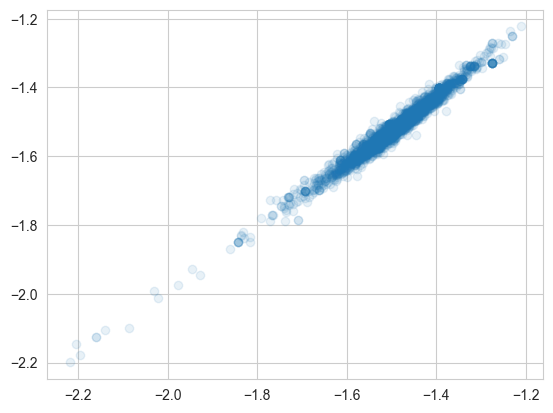

In [31]:
sb.set_style("whitegrid")
plt.scatter(df.panas_we_short_panas, df.panas_we_full_panas,
           alpha=0.1)
plt.show()

# Aggregate to User-level Measures

In [32]:
# Aggregate all posts

agg_all = df.groupby('participantCode').agg(
    
    # Character count
    cc_mean_all = pd.NamedAgg(column="cc", aggfunc="mean"),
    cc_sum_all = pd.NamedAgg(column="cc", aggfunc="sum"),
    cc_median_all = pd.NamedAgg(column="cc", aggfunc="median"),
    
    # Word count
    wc_mean_all = pd.NamedAgg(column="wc", aggfunc="mean"),
    wc_sum_all = pd.NamedAgg(column="wc", aggfunc="sum"),
    wc_median_all = pd.NamedAgg(column="wc", aggfunc="median"),

    # Exclamation points
    exc_mean_all = pd.NamedAgg(column="exc", aggfunc="mean"),
    exc_sum_all = pd.NamedAgg(column="exc", aggfunc="sum"),

    # Emoji - Positive
    emoji_pos_mean_all = pd.NamedAgg(column="emoji_pos", aggfunc="mean"),
    emoji_pos_median_all = pd.NamedAgg(column="emoji_pos", aggfunc="median"),

    # Emoji - Negative
    emoji_neg_mean_all = pd.NamedAgg(column="emoji_neg", aggfunc="mean"),
    emoji_neg_median_all = pd.NamedAgg(column="emoji_neg", aggfunc="median"),

    # Emoji - Sentiment
    emoji_sent_mean_all = pd.NamedAgg(column="emoji_sent", aggfunc="mean"),
    emoji_sent_median_all = pd.NamedAgg(column="emoji_sent", aggfunc="median"),

    # Full PANAS (WE) - Positive
    we_full_pos_mean_all = pd.NamedAgg(column="panas_we_full_pos", aggfunc="mean"),
    we_full_pos_median_all = pd.NamedAgg(column="panas_we_full_pos", aggfunc="median"),

    # Full PANAS (WE) - Negative
    we_full_neg_mean_all = pd.NamedAgg(column="panas_we_full_neg", aggfunc="mean"),
    we_full_neg_median_all = pd.NamedAgg(column="panas_we_full_neg", aggfunc="median"),

    # Full PANAS (WE) - Overall
    we_full_panas_mean_all = pd.NamedAgg(column="panas_we_full_panas", aggfunc="mean"),
    we_full_panas_median_all = pd.NamedAgg(column="panas_we_full_panas", aggfunc="median"),

    # Short PANAS (WE) - Positive
    we_short_pos_mean_all = pd.NamedAgg(column="panas_we_short_pos", aggfunc="mean"),
    we_short_pos_median_all = pd.NamedAgg(column="panas_we_short_pos", aggfunc="median"),

    # Short PANAS (WE) - Negative
    we_short_neg_mean_all = pd.NamedAgg(column="panas_we_short_neg", aggfunc="mean"),
    we_short_neg_median_all = pd.NamedAgg(column="panas_we_short_neg", aggfunc="median"),

    # Short PANAS (WE) - Overall
    we_short_panas_mean_all = pd.NamedAgg(column="panas_we_short_panas", aggfunc="mean"),
    we_short_panas_median_all = pd.NamedAgg(column="panas_we_short_panas", aggfunc="median"),

    num_messages_all =pd.NamedAgg(column="cc", aggfunc="size")
).reset_index()

agg_all

,participantCode,cc_mean_all,cc_sum_all,cc_median_all,wc_mean_all,wc_sum_all,wc_median_all,exc_mean_all,exc_sum_all,emoji_pos_mean_all,...,we_full_neg_median_all,we_full_panas_mean_all,we_full_panas_median_all,we_short_pos_mean_all,we_short_pos_median_all,we_short_neg_mean_all,we_short_neg_median_all,we_short_panas_mean_all,we_short_panas_median_all,num_messages_all
0,11b468,242.333333,727,228.0,46.000000,138,45.0,0.000000,0,NaN,...,0.201753,-1.583971,-1.583924,0.206121,0.201468,0.245919,0.235261,-1.547960,-1.563271,3
1,11frdz,122.750000,491,88.5,24.500000,98,16.5,0.250000,1,NaN,...,0.200734,-1.568941,-1.574763,0.212995,0.208500,0.251373,0.247516,-1.535632,-1.543984,4
2,11g3d4,48.000000,48,48.0,12.000000,12,12.0,0.000000,0,NaN,...,0.167374,-1.632998,-1.632998,0.186090,0.186090,0.202036,0.202036,-1.611873,-1.611873,1
3,11uby7,201.000000,402,201.0,38.500000,77,38.5,0.000000,0,NaN,...,0.244750,-1.508937,-1.508937,0.238323,0.238323,0.292072,0.292072,-1.469605,-1.469605,2
4,12cpx2,82.750000,993,78.0,17.666667,212,18.0,0.166667,2,NaN,...,0.243811,-1.515523,-1.543483,0.209385,0.208889,0.292764,0.300900,-1.497851,-1.528489,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,zxyz1h,34.250000,548,32.0,7.875000,126,7.5,0.000000,0,0.291,...,0.246688,-1.507790,-1.505363,0.208292,0.205320,0.295474,0.289546,-1.496234,-1.505692,16
977,zy6tqc,58.100000,581,58.5,12.300000,123,12.0,0.600000,6,NaN,...,0.241702,-1.498744,-1.498551,0.237869,0.232829,0.283923,0.292331,-1.478208,-1.474695,10
978,zywuwt,30.333333,91,31.0,5.333333,16,5.0,0.000000,0,NaN,...,0.238597,-1.530769,-1.540730,0.193930,0.215526,0.304238,0.284328,-1.501832,-1.500146,3
979,zzmpme,93.000000,93,93.0,18.000000,18,18.0,0.000000,0,NaN,...,0.245934,-1.489779,-1.489779,0.247778,0.247778,0.307913,0.307913,-1.444309,-1.444309,1


In [33]:
# Aggregate all original posts

df_op = df[pd.isnull(df.parentPost)]

agg_op = df_op.groupby('participantCode').agg(
    
    # Character count
    cc_mean_op = pd.NamedAgg(column="cc", aggfunc="mean"),
    cc_sum_op = pd.NamedAgg(column="cc", aggfunc="sum"),
    cc_median_op = pd.NamedAgg(column="cc", aggfunc="median"),
    
    # Word count
    wc_mean_op = pd.NamedAgg(column="wc", aggfunc="mean"),
    wc_sum_op = pd.NamedAgg(column="wc", aggfunc="sum"),
    wc_median_op = pd.NamedAgg(column="wc", aggfunc="median"),

    # Exclamation Points
    exc_mean_op = pd.NamedAgg(column="exc", aggfunc="mean"),
    exc_sum_op = pd.NamedAgg(column="exc", aggfunc="sum"),

    # Emoji - Positive
    emoji_pos_mean_op = pd.NamedAgg(column="emoji_pos", aggfunc="mean"),
    emoji_pos_median_op = pd.NamedAgg(column="emoji_pos", aggfunc="median"),

    # Emoji - Negative
    emoji_neg_mean_op = pd.NamedAgg(column="emoji_neg", aggfunc="mean"),
    emoji_neg_median_op = pd.NamedAgg(column="emoji_neg", aggfunc="median"),

    # Emoji - Sentiment
    emoji_sent_mean_op = pd.NamedAgg(column="emoji_sent", aggfunc="mean"),
    emoji_sent_median_op = pd.NamedAgg(column="emoji_sent", aggfunc="median"),

    # Full PANAS (WE) - Positive
    we_full_pos_mean_op = pd.NamedAgg(column="panas_we_full_pos", aggfunc="mean"),
    we_full_pos_median_op = pd.NamedAgg(column="panas_we_full_pos", aggfunc="median"),

    # Full PANAS (WE) - Negative
    we_full_neg_mean_op = pd.NamedAgg(column="panas_we_full_neg", aggfunc="mean"),
    we_full_neg_median_op = pd.NamedAgg(column="panas_we_full_neg", aggfunc="median"),

    # Full PANAS (WE) - Overall
    we_full_panas_mean_op = pd.NamedAgg(column="panas_we_full_panas", aggfunc="mean"),
    we_full_panas_median_op = pd.NamedAgg(column="panas_we_full_panas", aggfunc="median"),

    # Short PANAS (WE) - Positive
    we_short_pos_mean_op = pd.NamedAgg(column="panas_we_short_pos", aggfunc="mean"),
    we_short_pos_median_op = pd.NamedAgg(column="panas_we_short_pos", aggfunc="median"),

    # Short PANAS (WE) - Negative
    we_short_neg_mean_op = pd.NamedAgg(column="panas_we_short_neg", aggfunc="mean"),
    we_short_neg_median_op = pd.NamedAgg(column="panas_we_short_neg", aggfunc="median"),

    # Short PANAS (WE) - Overall
    we_short_panas_mean_op = pd.NamedAgg(column="panas_we_short_panas", aggfunc="mean"),
    we_short_panas_median_op = pd.NamedAgg(column="panas_we_short_panas", aggfunc="median"),

    num_messages_op =pd.NamedAgg(column="cc", aggfunc="size")
).reset_index()

agg_op

,participantCode,cc_mean_op,cc_sum_op,cc_median_op,wc_mean_op,wc_sum_op,wc_median_op,exc_mean_op,exc_sum_op,emoji_pos_mean_op,...,we_full_neg_median_op,we_full_panas_mean_op,we_full_panas_median_op,we_short_pos_mean_op,we_short_pos_median_op,we_short_neg_mean_op,we_short_neg_median_op,we_short_panas_mean_op,we_short_panas_median_op,num_messages_op
0,11b468,278.000000,278,278.0,56.000000,56,56.0,0.000000,0,NaN,...,0.229943,-1.543407,-1.543407,0.222147,0.222147,0.278273,0.278273,-1.499581,-1.499581,1
1,11frdz,288.000000,288,288.0,61.000000,61,61.0,0.000000,0,NaN,...,0.198363,-1.579621,-1.579621,0.211193,0.211193,0.241454,0.241454,-1.547353,-1.547353,1
2,11g3d4,48.000000,48,48.0,12.000000,12,12.0,0.000000,0,NaN,...,0.167374,-1.632998,-1.632998,0.186090,0.186090,0.202036,0.202036,-1.611873,-1.611873,1
3,11uby7,255.000000,255,255.0,48.000000,48,48.0,0.000000,0,NaN,...,0.229186,-1.525278,-1.525278,0.231132,0.231132,0.275491,0.275491,-1.493377,-1.493377,1
4,12cpx2,152.000000,304,152.0,33.500000,67,33.5,1.000000,2,NaN,...,0.213015,-1.556256,-1.556256,0.199798,0.199798,0.260689,0.260689,-1.539512,-1.539512,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,zxyz1h,38.000000,114,34.0,9.333333,28,10.0,0.000000,0,NaN,...,0.218866,-1.584360,-1.556318,0.175885,0.188963,0.246341,0.255692,-1.577774,-1.555345,3
875,zy6tqc,96.666667,290,97.0,20.666667,62,22.0,0.666667,2,NaN,...,0.249250,-1.480138,-1.467697,0.247354,0.250928,0.297417,0.307002,-1.455228,-1.437718,3
876,zywuwt,55.000000,55,55.0,10.000000,10,10.0,0.000000,0,NaN,...,0.276365,-1.431448,-1.431448,0.257425,0.257425,0.344952,0.344952,-1.397623,-1.397623,1
877,zzmpme,93.000000,93,93.0,18.000000,18,18.0,0.000000,0,NaN,...,0.245934,-1.489779,-1.489779,0.247778,0.247778,0.307913,0.307913,-1.444309,-1.444309,1


In [34]:
# Aggregate all comments

df_comm = df[pd.notnull(df.parentPost)]

agg_comm = df_comm.groupby('participantCode').agg(
    
    # Character count
    cc_mean_comm = pd.NamedAgg(column="cc", aggfunc="mean"),
    cc_sum_comm = pd.NamedAgg(column="cc", aggfunc="sum"),
    cc_median_comm = pd.NamedAgg(column="cc", aggfunc="median"),
    
    # Word count
    wc_mean_comm = pd.NamedAgg(column="wc", aggfunc="mean"),
    wc_sum_comm = pd.NamedAgg(column="wc", aggfunc="sum"),
    wc_median_comm = pd.NamedAgg(column="wc", aggfunc="median"),

    # Exclamation Points
    exc_mean_comm = pd.NamedAgg(column="exc", aggfunc="mean"),
    exc_sum_comm = pd.NamedAgg(column="exc", aggfunc="sum"),

    # Emoji - Positive
    emoji_pos_mean_comm = pd.NamedAgg(column="emoji_pos", aggfunc="mean"),
    emoji_pos_median_comm = pd.NamedAgg(column="emoji_pos", aggfunc="median"),

    # Emoji - Negative
    emoji_neg_mean_comm = pd.NamedAgg(column="emoji_neg", aggfunc="mean"),
    emoji_neg_median_comm = pd.NamedAgg(column="emoji_neg", aggfunc="median"),

    # Emoji - Sentiment
    emoji_sent_mean_comm = pd.NamedAgg(column="emoji_sent", aggfunc="mean"),
    emoji_sent_median_comm = pd.NamedAgg(column="emoji_sent", aggfunc="median"),

    # Full PANAS (WE) - Positive
    we_full_pos_mean_comm = pd.NamedAgg(column="panas_we_full_pos", aggfunc="mean"),
    we_full_pos_median_comm = pd.NamedAgg(column="panas_we_full_pos", aggfunc="median"),

    # Full PANAS (WE) - Negative
    we_full_neg_mean_comm = pd.NamedAgg(column="panas_we_full_neg", aggfunc="mean"),
    we_full_neg_median_comm = pd.NamedAgg(column="panas_we_full_neg", aggfunc="median"),

    # Full PANAS (WE) - Overall
    we_full_panas_mean_comm = pd.NamedAgg(column="panas_we_full_panas", aggfunc="mean"),
    we_full_panas_median_comm = pd.NamedAgg(column="panas_we_full_panas", aggfunc="median"),

    # Short PANAS (WE) - Positive
    we_short_pos_mean_comm = pd.NamedAgg(column="panas_we_short_pos", aggfunc="mean"),
    we_short_pos_median_comm = pd.NamedAgg(column="panas_we_short_pos", aggfunc="median"),

    # Short PANAS (WE) - Negative
    we_short_neg_mean_comm = pd.NamedAgg(column="panas_we_short_neg", aggfunc="mean"),
    we_short_neg_median_comm = pd.NamedAgg(column="panas_we_short_neg", aggfunc="median"),

    # Short PANAS (WE) - Overall
    we_short_panas_mean_comm = pd.NamedAgg(column="panas_we_short_panas", aggfunc="mean"),
    we_short_panas_median_comm = pd.NamedAgg(column="panas_we_short_panas", aggfunc="median"),

    num_messages_comm =pd.NamedAgg(column="cc", aggfunc="size")
).reset_index()

agg_comm

,participantCode,cc_mean_comm,cc_sum_comm,cc_median_comm,wc_mean_comm,wc_sum_comm,wc_median_comm,exc_mean_comm,exc_sum_comm,emoji_pos_mean_comm,...,we_full_neg_median_comm,we_full_panas_mean_comm,we_full_panas_median_comm,we_short_pos_mean_comm,we_short_pos_median_comm,we_short_neg_mean_comm,we_short_neg_median_comm,we_short_panas_mean_comm,we_short_panas_median_comm,num_messages_comm
0,11b468,224.500000,449,224.5,41.000000,82,41.0,0.000000,0,NaN,...,0.191244,-1.604253,-1.604253,0.198108,0.198108,0.229742,0.229742,-1.572150,-1.572150,2
1,11frdz,67.666667,203,55.0,12.333333,37,11.0,0.333333,1,NaN,...,0.203105,-1.565381,-1.569904,0.213596,0.205808,0.254679,0.253578,-1.531725,-1.540614,3
2,11uby7,147.000000,147,147.0,29.000000,29,29.0,0.000000,0,NaN,...,0.260315,-1.492595,-1.492595,0.245514,0.245514,0.308653,0.308653,-1.445833,-1.445833,1
3,12cpx2,68.900000,689,72.5,14.500000,145,13.5,0.000000,0,NaN,...,0.248722,-1.507376,-1.521088,0.211303,0.219960,0.299179,0.302880,-1.489518,-1.505217,10
4,16rhru,97.000000,388,67.0,19.500000,78,13.0,0.000000,0,0.720,...,0.218017,-1.571839,-1.553755,0.210660,0.210248,0.252133,0.273023,-1.537208,-1.512367,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,zwtg94,211.000000,422,211.0,46.000000,92,46.0,0.000000,0,NaN,...,0.238826,-1.485492,-1.485492,0.247658,0.247658,0.289604,0.289604,-1.462737,-1.462737,2
866,zxyz1h,33.384615,434,30.0,7.538462,98,7.0,0.000000,0,0.291,...,0.248927,-1.490119,-1.481845,0.215770,0.207514,0.306812,0.306513,-1.477418,-1.473914,13
867,zy6tqc,41.571429,291,55.0,8.714286,61,11.0,0.571429,4,NaN,...,0.241214,-1.506718,-1.504922,0.233803,0.230852,0.278140,0.290471,-1.488057,-1.479280,7
868,zywuwt,18.000000,36,18.0,3.000000,6,3.0,0.000000,0,NaN,...,0.237930,-1.580429,-1.580429,0.162183,0.162183,0.283881,0.283881,-1.553936,-1.553936,2


In [35]:
# Aggregate all comments on IH posts

df_ih = df[[i in ih for i in df.parentPost]]

agg_ih = df_ih.groupby('participantCode').agg(
    
    # Character count
    cc_mean_ih = pd.NamedAgg(column="cc", aggfunc="mean"),
    cc_sum_ih = pd.NamedAgg(column="cc", aggfunc="sum"),
    cc_median_ih = pd.NamedAgg(column="cc", aggfunc="median"),
    
    # Word count
    wc_mean_ih = pd.NamedAgg(column="wc", aggfunc="mean"),
    wc_sum_ih = pd.NamedAgg(column="wc", aggfunc="sum"),
    wc_median_ih = pd.NamedAgg(column="wc", aggfunc="median"),

    # Exclamation Points
    exc_mean_ih = pd.NamedAgg(column="exc", aggfunc="mean"),
    exc_sum_ih = pd.NamedAgg(column="exc", aggfunc="sum"),

    # Emoji - Positive
    emoji_pos_mean_ih = pd.NamedAgg(column="emoji_pos", aggfunc="mean"),
    emoji_pos_median_ih = pd.NamedAgg(column="emoji_pos", aggfunc="median"),

    # Emoji - Negative
    emoji_neg_mean_ih = pd.NamedAgg(column="emoji_neg", aggfunc="mean"),
    emoji_neg_median_ih = pd.NamedAgg(column="emoji_neg", aggfunc="median"),

    # Emoji - Sentiment
    emoji_sent_mean_ih = pd.NamedAgg(column="emoji_sent", aggfunc="mean"),
    emoji_sent_median_ih = pd.NamedAgg(column="emoji_sent", aggfunc="median"),

    # Full PANAS (WE) - Positive
    we_full_pos_mean_ih = pd.NamedAgg(column="panas_we_full_pos", aggfunc="mean"),
    we_full_pos_median_ih = pd.NamedAgg(column="panas_we_full_pos", aggfunc="median"),

    # Full PANAS (WE) - Negative
    we_full_neg_mean_ih = pd.NamedAgg(column="panas_we_full_neg", aggfunc="mean"),
    we_full_neg_median_ih = pd.NamedAgg(column="panas_we_full_neg", aggfunc="median"),

    # Full PANAS (WE) - Overall
    we_full_panas_mean_ih = pd.NamedAgg(column="panas_we_full_panas", aggfunc="mean"),
    we_full_panas_median_ih = pd.NamedAgg(column="panas_we_full_panas", aggfunc="median"),

    # Short PANAS (WE) - Positive
    we_short_pos_mean_ih = pd.NamedAgg(column="panas_we_short_pos", aggfunc="mean"),
    we_short_pos_median_ih = pd.NamedAgg(column="panas_we_short_pos", aggfunc="median"),

    # Short PANAS (WE) - Negative
    we_short_neg_mean_ih = pd.NamedAgg(column="panas_we_short_neg", aggfunc="mean"),
    we_short_neg_median_ih = pd.NamedAgg(column="panas_we_short_neg", aggfunc="median"),

    # Short PANAS (WE) - Overall
    we_short_panas_mean_ih = pd.NamedAgg(column="panas_we_short_panas", aggfunc="mean"),
    we_short_panas_median_ih = pd.NamedAgg(column="panas_we_short_panas", aggfunc="median"),

    num_messages_ih =pd.NamedAgg(column="cc", aggfunc="size")
).reset_index()

agg_ih

,participantCode,cc_mean_ih,cc_sum_ih,cc_median_ih,wc_mean_ih,wc_sum_ih,wc_median_ih,exc_mean_ih,exc_sum_ih,emoji_pos_mean_ih,...,we_full_neg_median_ih,we_full_panas_mean_ih,we_full_panas_median_ih,we_short_pos_mean_ih,we_short_pos_median_ih,we_short_neg_mean_ih,we_short_neg_median_ih,we_short_panas_mean_ih,we_short_panas_median_ih,num_messages_ih
0,11frdz,67.666667,203,55.0,12.333333,37,11.0,0.333333,1,NaN,...,0.203105,-1.565381,-1.569904,0.213596,0.205808,0.254679,0.253578,-1.531725,-1.540614,3
1,17xpyv,94.000000,94,94.0,19.000000,19,19.0,0.000000,0,NaN,...,0.273386,-1.404358,-1.404358,0.294325,0.294325,0.326710,0.326710,-1.378965,-1.378965,1
2,1bqxnq,22.000000,22,22.0,7.000000,7,7.0,1.000000,1,NaN,...,0.199239,-1.563555,-1.563555,0.185327,0.185327,0.251079,0.251079,-1.563594,-1.563594,1
3,1c87zz,126.000000,126,126.0,24.000000,24,24.0,0.000000,0,NaN,...,0.208995,-1.544120,-1.544120,0.225823,0.225823,0.257161,0.257161,-1.517015,-1.517015,1
4,1f4cwc,396.500000,793,396.5,82.500000,165,82.5,0.500000,1,NaN,...,0.232675,-1.518752,-1.518752,0.222638,0.222638,0.280638,0.280638,-1.496724,-1.496724,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,zu9wre,31.000000,31,31.0,6.000000,6,6.0,0.000000,0,NaN,...,0.212126,-1.504912,-1.504912,0.254321,0.254321,0.265123,0.265123,-1.480555,-1.480555,1
289,zvf1ru,44.000000,44,44.0,9.000000,9,9.0,1.000000,1,NaN,...,0.248337,-1.461036,-1.461036,0.259329,0.259329,0.310282,0.310282,-1.430389,-1.430389,1
290,zwphpx,64.400000,322,72.0,14.800000,74,17.0,0.000000,0,NaN,...,0.244113,-1.489034,-1.489897,0.251581,0.258974,0.291223,0.294651,-1.457196,-1.466846,5
291,zy6tqc,78.000000,78,78.0,14.000000,14,14.0,1.000000,1,NaN,...,0.191140,-1.544537,-1.544537,0.229797,0.229797,0.243658,0.243658,-1.526545,-1.526545,1


In [36]:
# Aggregate all comments on Lib posts

df_lib = df[[i in lib for i in df.parentPost]]

agg_lib = df_lib.groupby('participantCode').agg(
    
    # Character count
    cc_mean_lib = pd.NamedAgg(column="cc", aggfunc="mean"),
    cc_sum_lib = pd.NamedAgg(column="cc", aggfunc="sum"),
    cc_median_lib = pd.NamedAgg(column="cc", aggfunc="median"),
    
    # Word count
    wc_mean_lib = pd.NamedAgg(column="wc", aggfunc="mean"),
    wc_sum_lib = pd.NamedAgg(column="wc", aggfunc="sum"),
    wc_median_lib = pd.NamedAgg(column="wc", aggfunc="median"),

    # Exclamation Points
    exc_mean_lib = pd.NamedAgg(column="exc", aggfunc="mean"),
    exc_sum_lib = pd.NamedAgg(column="exc", aggfunc="sum"),

    # Emoji - Positive
    emoji_pos_mean_lib = pd.NamedAgg(column="emoji_pos", aggfunc="mean"),
    emoji_pos_median_lib = pd.NamedAgg(column="emoji_pos", aggfunc="median"),

    # Emoji - Negative
    emoji_neg_mean_lib = pd.NamedAgg(column="emoji_neg", aggfunc="mean"),
    emoji_neg_median_lib = pd.NamedAgg(column="emoji_neg", aggfunc="median"),

    # Emoji - Sentiment
    emoji_sent_mean_lib = pd.NamedAgg(column="emoji_sent", aggfunc="mean"),
    emoji_sent_median_lib = pd.NamedAgg(column="emoji_sent", aggfunc="median"),

    # Full PANAS (WE) - Positive
    we_full_pos_mean_lib = pd.NamedAgg(column="panas_we_full_pos", aggfunc="mean"),
    we_full_pos_median_lib = pd.NamedAgg(column="panas_we_full_pos", aggfunc="median"),

    # Full PANAS (WE) - Negative
    we_full_neg_mean_lib = pd.NamedAgg(column="panas_we_full_neg", aggfunc="mean"),
    we_full_neg_median_lib = pd.NamedAgg(column="panas_we_full_neg", aggfunc="median"),

    # Full PANAS (WE) - Overall
    we_full_panas_mean_lib = pd.NamedAgg(column="panas_we_full_panas", aggfunc="mean"),
    we_full_panas_median_lib = pd.NamedAgg(column="panas_we_full_panas", aggfunc="median"),

    # Short PANAS (WE) - Positive
    we_short_pos_mean_lib = pd.NamedAgg(column="panas_we_short_pos", aggfunc="mean"),
    we_short_pos_median_lib = pd.NamedAgg(column="panas_we_short_pos", aggfunc="median"),

    # Short PANAS (WE) - Negative
    we_short_neg_mean_lib = pd.NamedAgg(column="panas_we_short_neg", aggfunc="mean"),
    we_short_neg_median_lib = pd.NamedAgg(column="panas_we_short_neg", aggfunc="median"),

    # Short PANAS (WE) - Overall
    we_short_panas_mean_lib = pd.NamedAgg(column="panas_we_short_panas", aggfunc="mean"),
    we_short_panas_median_lib = pd.NamedAgg(column="panas_we_short_panas", aggfunc="median"),

    num_messages_lib =pd.NamedAgg(column="cc", aggfunc="size")
).reset_index()

agg_lib

,participantCode,cc_mean_lib,cc_sum_lib,cc_median_lib,wc_mean_lib,wc_sum_lib,wc_median_lib,exc_mean_lib,exc_sum_lib,emoji_pos_mean_lib,...,we_full_neg_median_lib,we_full_panas_mean_lib,we_full_panas_median_lib,we_short_pos_mean_lib,we_short_pos_median_lib,we_short_neg_mean_lib,we_short_neg_median_lib,we_short_panas_mean_lib,we_short_panas_median_lib,num_messages_lib
0,11b468,221.000000,221,221.0,37.000000,37,37.0,0.0,0,NaN,...,0.180734,-1.624582,-1.624582,0.194747,0.194747,0.224223,0.224223,-1.581030,-1.581030,1
1,11frdz,55.000000,55,55.0,11.000000,11,11.0,1.0,1,NaN,...,0.203105,-1.569904,-1.569904,0.205808,0.205808,0.253578,0.253578,-1.540614,-1.540614,1
2,12cpx2,67.750000,271,60.0,15.750000,63,15.5,0.0,0,NaN,...,0.241933,-1.549262,-1.567631,0.188503,0.184063,0.279561,0.291533,-1.531936,-1.556190,4
3,16rhru,119.666667,359,104.0,23.333333,70,18.0,0.0,0,NaN,...,0.225448,-1.541720,-1.546466,0.224045,0.216259,0.279880,0.284869,-1.496075,-1.502169,3
4,1art8b,110.000000,110,110.0,19.000000,19,19.0,0.0,0,NaN,...,0.205728,-1.549988,-1.549988,0.232156,0.232156,0.254608,0.254608,-1.513237,-1.513237,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,zwcmc7,8.000000,8,8.0,2.000000,2,2.0,0.0,0,NaN,...,0.294122,-1.400592,-1.400592,0.227238,0.227238,0.380251,0.380251,-1.392511,-1.392511,1
466,zwphpx,8.000000,8,8.0,3.000000,3,3.0,1.0,1,NaN,...,0.222071,-1.505076,-1.505076,0.207432,0.207432,0.288386,0.288386,-1.504181,-1.504181,1
467,zxyz1h,14.000000,28,14.0,3.500000,7,3.5,0.0,0,NaN,...,0.284312,-1.443435,-1.443435,0.205320,0.205320,0.348135,0.348135,-1.446545,-1.446545,2
468,zy6tqc,37.000000,74,37.0,8.000000,16,8.0,1.0,2,NaN,...,0.225874,-1.483481,-1.483481,0.246443,0.246443,0.282271,0.282271,-1.471285,-1.471285,2


In [37]:
# Aggregate all comments on Con posts

df_con = df[[i in con for i in df.parentPost]]

agg_con = df_con.groupby('participantCode').agg(
    
    # Character count
    cc_mean_con = pd.NamedAgg(column="cc", aggfunc="mean"),
    cc_sum_con = pd.NamedAgg(column="cc", aggfunc="sum"),
    cc_median_con = pd.NamedAgg(column="cc", aggfunc="median"),
    
    # Word count
    wc_mean_con = pd.NamedAgg(column="wc", aggfunc="mean"),
    wc_sum_con = pd.NamedAgg(column="wc", aggfunc="sum"),
    wc_median_con = pd.NamedAgg(column="wc", aggfunc="median"),

    # Exclamation Points
    exc_mean_con = pd.NamedAgg(column="exc", aggfunc="mean"),
    exc_sum_con = pd.NamedAgg(column="exc", aggfunc="sum"),

    # Emoji - Positive
    emoji_pos_mean_con = pd.NamedAgg(column="emoji_pos", aggfunc="mean"),
    emoji_pos_median_con = pd.NamedAgg(column="emoji_pos", aggfunc="median"),

    # Emoji - Negative
    emoji_neg_mean_con = pd.NamedAgg(column="emoji_neg", aggfunc="mean"),
    emoji_neg_median_con = pd.NamedAgg(column="emoji_neg", aggfunc="median"),

    # Emoji - Sentiment
    emoji_sent_mean_con = pd.NamedAgg(column="emoji_sent", aggfunc="mean"),
    emoji_sent_median_con = pd.NamedAgg(column="emoji_sent", aggfunc="median"),

    # Full PANAS (WE) - Positive
    we_full_pos_mean_con = pd.NamedAgg(column="panas_we_full_pos", aggfunc="mean"),
    we_full_pos_median_con = pd.NamedAgg(column="panas_we_full_pos", aggfunc="median"),

    # Full PANAS (WE) - Negative
    we_full_neg_mean_con = pd.NamedAgg(column="panas_we_full_neg", aggfunc="mean"),
    we_full_neg_median_con = pd.NamedAgg(column="panas_we_full_neg", aggfunc="median"),

    # Full PANAS (WE) - Overall
    we_full_panas_mean_con = pd.NamedAgg(column="panas_we_full_panas", aggfunc="mean"),
    we_full_panas_median_con = pd.NamedAgg(column="panas_we_full_panas", aggfunc="median"),

    # Short PANAS (WE) - Positive
    we_short_pos_mean_con = pd.NamedAgg(column="panas_we_short_pos", aggfunc="mean"),
    we_short_pos_median_con = pd.NamedAgg(column="panas_we_short_pos", aggfunc="median"),

    # Short PANAS (WE) - Negative
    we_short_neg_mean_con = pd.NamedAgg(column="panas_we_short_neg", aggfunc="mean"),
    we_short_neg_median_con = pd.NamedAgg(column="panas_we_short_neg", aggfunc="median"),

    # Short PANAS (WE) - Overall
    we_short_panas_mean_con = pd.NamedAgg(column="panas_we_short_panas", aggfunc="mean"),
    we_short_panas_median_con = pd.NamedAgg(column="panas_we_short_panas", aggfunc="median"),

    num_messages_con =pd.NamedAgg(column="cc", aggfunc="size")
).reset_index()

agg_con

,participantCode,cc_mean_con,cc_sum_con,cc_median_con,wc_mean_con,wc_sum_con,wc_median_con,exc_mean_con,exc_sum_con,emoji_pos_mean_con,...,we_full_neg_median_con,we_full_panas_mean_con,we_full_panas_median_con,we_short_pos_mean_con,we_short_pos_median_con,we_short_neg_mean_con,we_short_neg_median_con,we_short_panas_mean_con,we_short_panas_median_con,num_messages_con
0,11b468,228.000000,228,228.0,45.000000,45,45.0,0.0,0,NaN,...,0.201753,-1.583924,-1.583924,0.201468,0.201468,0.235261,0.235261,-1.563271,-1.563271,1
1,11frdz,74.000000,148,74.0,13.000000,26,13.0,0.0,0,NaN,...,0.213402,-1.563119,-1.563119,0.217490,0.217490,0.255230,0.255230,-1.527280,-1.527280,2
2,11uby7,147.000000,147,147.0,29.000000,29,29.0,0.0,0,NaN,...,0.260315,-1.492595,-1.492595,0.245514,0.245514,0.308653,0.308653,-1.445833,-1.445833,1
3,12cpx2,91.500000,366,91.5,17.750000,71,19.0,0.0,0,NaN,...,0.254104,-1.453246,-1.449003,0.250347,0.259575,0.317688,0.310496,-1.431965,-1.429929,4
4,17xpyv,94.000000,94,94.0,19.000000,19,19.0,0.0,0,NaN,...,0.273386,-1.404358,-1.404358,0.294325,0.294325,0.326710,0.326710,-1.378965,-1.378965,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,zv3m1r,112.000000,224,112.0,25.000000,50,25.0,0.0,0,NaN,...,0.242162,-1.529321,-1.529321,0.199652,0.199652,0.293135,0.293135,-1.507212,-1.507212,2
501,zwphpx,57.166667,343,69.0,13.166667,79,16.0,0.0,0,NaN,...,0.239649,-1.498805,-1.500477,0.247578,0.252237,0.289442,0.288395,-1.462980,-1.469603,6
502,zxyz1h,10.500000,21,10.5,2.500000,5,2.5,0.0,0,NaN,...,0.292146,-1.452660,-1.452660,0.225730,0.225730,0.363402,0.363402,-1.410868,-1.410868,2
503,zy6tqc,78.000000,78,78.0,14.000000,14,14.0,1.0,1,NaN,...,0.191140,-1.544537,-1.544537,0.229797,0.229797,0.243658,0.243658,-1.526545,-1.526545,1


In [38]:
# Combine the aggregated data

content_df = agg_all

for agg in [agg_op, agg_comm, agg_ih, agg_con, agg_lib]:
    content_df = content_df.merge(agg, on='participantCode', how="left")

content_df = content_df.fillna(value={'num_messages_op':0,
                                      'num_messages_comm':0,
                                      'num_messages_ih':0,
                                      'num_messages_con':0,
                                      'num_messages_lib':0})

content_df
    

,participantCode,cc_mean_all,cc_sum_all,cc_median_all,wc_mean_all,wc_sum_all,wc_median_all,exc_mean_all,exc_sum_all,emoji_pos_mean_all,...,we_full_neg_median_lib,we_full_panas_mean_lib,we_full_panas_median_lib,we_short_pos_mean_lib,we_short_pos_median_lib,we_short_neg_mean_lib,we_short_neg_median_lib,we_short_panas_mean_lib,we_short_panas_median_lib,num_messages_lib
0,11b468,242.333333,727,228.0,46.000000,138,45.0,0.000000,0,NaN,...,0.180734,-1.624582,-1.624582,0.194747,0.194747,0.224223,0.224223,-1.581030,-1.581030,1.0
1,11frdz,122.750000,491,88.5,24.500000,98,16.5,0.250000,1,NaN,...,0.203105,-1.569904,-1.569904,0.205808,0.205808,0.253578,0.253578,-1.540614,-1.540614,1.0
2,11g3d4,48.000000,48,48.0,12.000000,12,12.0,0.000000,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11uby7,201.000000,402,201.0,38.500000,77,38.5,0.000000,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,12cpx2,82.750000,993,78.0,17.666667,212,18.0,0.166667,2,NaN,...,0.241933,-1.549262,-1.567631,0.188503,0.184063,0.279561,0.291533,-1.531936,-1.556190,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,zxyz1h,34.250000,548,32.0,7.875000,126,7.5,0.000000,0,0.291,...,0.284312,-1.443435,-1.443435,0.205320,0.205320,0.348135,0.348135,-1.446545,-1.446545,2.0
977,zy6tqc,58.100000,581,58.5,12.300000,123,12.0,0.600000,6,NaN,...,0.225874,-1.483481,-1.483481,0.246443,0.246443,0.282271,0.282271,-1.471285,-1.471285,2.0
978,zywuwt,30.333333,91,31.0,5.333333,16,5.0,0.000000,0,NaN,...,0.237263,-1.620127,-1.620127,0.108840,0.108840,0.283435,0.283435,-1.607726,-1.607726,1.0
979,zzmpme,93.000000,93,93.0,18.000000,18,18.0,0.000000,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


# Merge with Participant Data

In [39]:
user_df = pd.read_csv("Cleaned_study_data.csv")
user_df

,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,Duration (in seconds)_post,Finished_post,RecordedDate_post,ResponseId_post,RecipientLastName_post,...,ih_dwell_p,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star
0,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.71.112.54,100,217,True,12/12/2023 10:37,R_2ARnUkZ40c702IE,NaN,...,0.220734,1,1,2,1,0,1,1,True,0
1,12/12/2023 10:46,12/12/2023 10:52,IP Address,172.58.10.215,100,374,True,12/12/2023 10:52,R_27amtKO2JE7Iho9,NaN,...,0.109973,1,1,1,1,1,1,1,True,1
2,12/12/2023 10:47,12/12/2023 10:56,IP Address,66.212.218.70,100,520,True,12/12/2023 10:56,R_2Cy58sTvdtprJbm,NaN,...,0.141557,1,1,1,1,1,1,1,True,1
3,12/12/2023 10:55,12/12/2023 11:00,IP Address,68.116.85.163,100,260,True,12/12/2023 11:00,R_3QXJjMxRbpGVqnN,NaN,...,0.036418,1,1,1,1,1,1,1,True,1
4,12/12/2023 10:52,12/12/2023 11:06,IP Address,174.215.176.210,100,885,True,12/12/2023 11:06,R_2YLnKFzaVR8F7Mj,NaN,...,0.181847,1,1,1,1,1,1,1,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,12/12/2023 11:18,12/12/2023 11:25,IP Address,73.3.224.41,93,434,False,12/15/2023 0:33,R_1ddeajwrFRZrG73,NaN,...,0.092647,1,1,5,1,1,1,1,True,1
1039,12/12/2023 11:59,12/12/2023 12:02,IP Address,100.40.186.229,93,189,False,12/15/2023 0:33,R_27fMb9wZPSEktas,NaN,...,0.342752,1,0,4,1,1,0,1,True,0
1040,12/12/2023 11:32,12/12/2023 11:35,IP Address,172.56.15.42,93,197,False,12/15/2023 0:33,R_2ZKzyLxSf1s9NeJ,NaN,...,0.209302,1,1,1,1,1,1,1,True,1
1041,12/13/2023 13:25,12/13/2023 13:29,IP Address,24.99.26.176,93,222,False,12/15/2023 0:33,R_15KKEVD99jKy9Di,NaN,...,0.000000,1,1,5,1,1,1,1,True,1


In [40]:
posit = {'Strongly agree': "lib",
         "Agree": "lib",
          'Somewhat agree': "lib",
          'Neither agree nor disagree': np.nan,
          'Somewhat disagree': "con",
         "Disagree": "con",
          'Strongly disagree': "con"}

def posit_func(x):
    if x.topic == "gun control":
        return posit[x.pre_policy_gc]
    elif x.topic == "immigration":
        return posit[x.pre_policy_imm]

user_df['posit'] = user_df.apply(posit_func,axis=1)

user_df[['posit','pre_policy_imm','pre_policy_gc',"topic"]]

,posit,pre_policy_imm,pre_policy_gc,topic
0,lib,Agree,Strongly agree,immigration
1,con,Strongly agree,Strongly disagree,gun control
2,con,Strongly disagree,Strongly agree,immigration
3,lib,Somewhat agree,Strongly agree,gun control
4,con,Disagree,Somewhat agree,immigration
...,...,...,...,...
1038,lib,Somewhat agree,Agree,immigration
1039,lib,Strongly agree,Strongly agree,immigration
1040,NaN,Neither agree nor disagree,Agree,immigration
1041,lib,Disagree,Strongly agree,gun control


In [41]:
len(user_df.participant_code)

1043

In [42]:
new_df = content_df.merge(user_df, left_on="participantCode", right_on="participant_code", how="right", validate="1:1")
new_df

,participantCode,cc_mean_all,cc_sum_all,cc_median_all,wc_mean_all,wc_sum_all,wc_median_all,exc_mean_all,exc_sum_all,emoji_pos_mean_all,...,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star,posit
0,8gch37,126.333333,379.0,122.0,27.000000,81.0,27.0,0.333333,1.0,NaN,...,1,1,2,1,0,1,1,True,0,lib
1,nyuhem,206.500000,413.0,206.5,39.000000,78.0,39.0,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,con
2,gw6r7f,24.000000,48.0,24.0,5.500000,11.0,5.5,1.000000,2.0,NaN,...,1,1,1,1,1,1,1,True,1,con
3,17xpyv,178.000000,356.0,178.0,34.000000,68.0,34.0,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,lib
4,hfyv7m,86.500000,173.0,86.5,17.500000,35.0,17.5,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,con
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,r9hyrv,69.166667,415.0,47.0,16.000000,96.0,10.5,0.333333,2.0,NaN,...,1,1,5,1,1,1,1,True,1,lib
1039,3naupc,81.250000,325.0,48.0,17.000000,68.0,10.5,0.000000,0.0,NaN,...,1,0,4,1,1,0,1,True,0,lib
1040,6fxpk1,32.500000,65.0,32.5,5.500000,11.0,5.5,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,NaN
1041,pwghnt,85.833333,515.0,98.0,18.000000,108.0,21.5,0.000000,0.0,NaN,...,1,1,5,1,1,1,1,True,1,lib


In [43]:
data = []

for ind, row in new_df.iterrows():
    datum = {"participantCode": row['participantCode']}

    if row.posit == "lib":

        # Character Count
        datum['cc_mean_ca'] = row.cc_mean_con
        datum['cc_sum_ca'] = row.cc_sum_con
        datum['cc_median_ca'] = row.cc_median_con

        # Word Count
        datum['wc_mean_ca'] = row.wc_mean_con
        datum['wc_sum_ca'] = row.wc_sum_con
        datum['wc_median_ca'] = row.wc_median_con     

        # Exclamation Points
        datum['exc_mean_ca'] = row.exc_mean_con
        datum['exc_sum_ca'] = row.exc_sum_con

        # Emoji - Positive
        datum['emoji_pos_mean_ca'] = row.emoji_pos_mean_con
        datum['emoji_pos_median_ca'] = row.emoji_pos_median_con

        # Emoji - Negative
        datum['emoji_neg_mean_ca'] = row.emoji_neg_mean_con
        datum['emoji_neg_median_ca'] = row.emoji_neg_median_con

        # Emoji - Sentiment
        datum['emoji_sent_mean_ca'] = row.emoji_sent_mean_con
        datum['emoji_sent_median_ca'] = row.emoji_sent_median_con

        # Full PANAS (WE) - Positive
        datum['we_full_pos_mean_ca'] = row.we_full_pos_mean_con
        datum['we_full_pos_median_ca'] = row.we_full_pos_median_con

        # Full PANAS (WE) - Negative
        datum['we_full_neg_mean_ca'] = row.we_full_neg_mean_con
        datum['we_full_neg_median_ca'] = row.we_full_neg_median_con

        # Full PANAS (WE) - Overall
        datum['we_full_panas_mean_ca'] = row.we_full_panas_mean_con
        datum['we_full_panas_median_ca'] = row.we_full_panas_median_con

        # Short PANAS (WE) - Positive
        datum['we_short_pos_mean_ca'] = row.we_short_pos_mean_con
        datum['we_short_pos_median_ca'] = row.we_short_pos_median_con

        # Short PANAS (WE) - Negative
        datum['we_short_neg_mean_ca'] = row.we_short_neg_mean_con
        datum['we_short_neg_median_ca'] = row.we_short_neg_median_con

        # Short PANAS (WE) - Overall
        datum['we_short_panas_mean_ca'] = row.we_short_panas_mean_con
        datum['we_short_panas_median_ca'] = row.we_short_panas_median_con

        # N messages
        datum['num_messages_ca'] = row.num_messages_con

    elif row.posit == "con":
        
        # Character Count
        datum['cc_mean_ca'] = row.cc_mean_lib
        datum['cc_sum_ca'] = row.cc_sum_lib
        datum['cc_median_ca'] = row.cc_median_lib

        # Word Count
        datum['wc_mean_ca'] = row.wc_mean_lib
        datum['wc_sum_ca'] = row.wc_sum_lib
        datum['wc_median_ca'] = row.wc_median_lib     

        # Exclamation Points
        datum['exc_mean_ca'] = row.exc_mean_lib
        datum['exc_sum_ca'] = row.exc_sum_lib

        # Emoji - Positive
        datum['emoji_pos_mean_ca'] = row.emoji_pos_mean_lib
        datum['emoji_pos_median_ca'] = row.emoji_pos_median_lib

        # Emoji - Negative
        datum['emoji_neg_mean_ca'] = row.emoji_neg_mean_lib
        datum['emoji_neg_median_ca'] = row.emoji_neg_median_lib

        # Emoji - Sentiment
        datum['emoji_sent_mean_ca'] = row.emoji_sent_mean_lib
        datum['emoji_sent_median_ca'] = row.emoji_sent_median_lib

        # Full PANAS (WE) - Positive
        datum['we_full_pos_mean_ca'] = row.we_full_pos_mean_lib
        datum['we_full_pos_median_ca'] = row.we_full_pos_median_lib

        # Full PANAS (WE) - Negative
        datum['we_full_neg_mean_ca'] = row.we_full_neg_mean_lib
        datum['we_full_neg_median_ca'] = row.we_full_neg_median_lib

        # Full PANAS (WE) - Overall
        datum['we_full_panas_mean_ca'] = row.we_full_panas_mean_lib
        datum['we_full_panas_median_ca'] = row.we_full_panas_median_lib

        # Short PANAS (WE) - Positive
        datum['we_short_pos_mean_ca'] = row.we_short_pos_mean_lib
        datum['we_short_pos_median_ca'] = row.we_short_pos_median_lib

        # Short PANAS (WE) - Negative
        datum['we_short_neg_mean_ca'] = row.we_short_neg_mean_lib
        datum['we_short_neg_median_ca'] = row.we_short_neg_median_lib

        # Short PANAS (WE) - Overall
        datum['we_short_panas_mean_ca'] = row.we_short_panas_mean_lib
        datum['we_short_panas_median_ca'] = row.we_short_panas_median_lib

        # N messages
        datum['num_messages_ca'] = row.num_messages_lib

    data.append(datum)

ca_df = pd.DataFrame(data)
ca_df

,participantCode,cc_mean_ca,cc_sum_ca,cc_median_ca,wc_mean_ca,wc_sum_ca,wc_median_ca,exc_mean_ca,exc_sum_ca,emoji_pos_mean_ca,...,we_full_neg_median_ca,we_full_panas_mean_ca,we_full_panas_median_ca,we_short_pos_mean_ca,we_short_pos_median_ca,we_short_neg_mean_ca,we_short_neg_median_ca,we_short_panas_mean_ca,we_short_panas_median_ca,num_messages_ca
0,8gch37,122.0,122.0,122.0,27.00,27.0,27.0,0.0,0.0,NaN,...,0.207946,-1.543095,-1.543095,0.232203,0.232203,0.254051,0.254051,-1.513746,-1.513746,1.0
1,nyuhem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,gw6r7f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,17xpyv,94.0,94.0,94.0,19.00,19.0,19.0,0.0,0.0,NaN,...,0.273386,-1.404358,-1.404358,0.294325,0.294325,0.326710,0.326710,-1.378965,-1.378965,1.0
4,hfyv7m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,r9hyrv,51.0,204.0,47.0,11.75,47.0,10.5,0.0,0.0,NaN,...,0.190431,-1.535280,-1.549072,0.220746,0.204985,0.264063,0.236070,-1.515191,-1.527423,4.0
1039,3naupc,17.0,34.0,17.0,3.50,7.0,3.5,0.0,0.0,NaN,...,0.255849,-1.478978,-1.478978,0.239464,0.239464,0.315160,0.315160,-1.445376,-1.445376,2.0
1040,6fxpk1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1041,pwghnt,7.0,7.0,7.0,2.00,2.0,2.0,0.0,0.0,NaN,...,0.128219,-1.697982,-1.697982,0.179963,0.179963,0.158366,0.158366,-1.661671,-1.661671,1.0


In [50]:
new_df

,participantCode,cc_mean_all,cc_sum_all,cc_median_all,wc_mean_all,wc_sum_all,wc_median_all,exc_mean_all,exc_sum_all,emoji_pos_mean_all,...,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star,posit
0,8gch37,126.333333,379.0,122.0,27.000000,81.0,27.0,0.333333,1.0,NaN,...,1,1,2,1,0,1,1,True,0,lib
1,nyuhem,206.500000,413.0,206.5,39.000000,78.0,39.0,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,con
2,gw6r7f,24.000000,48.0,24.0,5.500000,11.0,5.5,1.000000,2.0,NaN,...,1,1,1,1,1,1,1,True,1,con
3,17xpyv,178.000000,356.0,178.0,34.000000,68.0,34.0,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,lib
4,hfyv7m,86.500000,173.0,86.5,17.500000,35.0,17.5,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,con
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,r9hyrv,69.166667,415.0,47.0,16.000000,96.0,10.5,0.333333,2.0,NaN,...,1,1,5,1,1,1,1,True,1,lib
1039,3naupc,81.250000,325.0,48.0,17.000000,68.0,10.5,0.000000,0.0,NaN,...,1,0,4,1,1,0,1,True,0,lib
1040,6fxpk1,32.500000,65.0,32.5,5.500000,11.0,5.5,0.000000,0.0,NaN,...,1,1,1,1,1,1,1,True,1,NaN
1041,pwghnt,85.833333,515.0,98.0,18.000000,108.0,21.5,0.000000,0.0,NaN,...,1,1,5,1,1,1,1,True,1,lib


In [52]:
(new_df.participantCode == ca_df.participantCode).mean()

0.9405560882070949

In [53]:
new_df.merge(ca_df, on="participantCode", how="inner")

,participantCode,cc_mean_all,cc_sum_all,cc_median_all,wc_mean_all,wc_sum_all,wc_median_all,exc_mean_all,exc_sum_all,emoji_pos_mean_all,...,we_full_neg_median_ca,we_full_panas_mean_ca,we_full_panas_median_ca,we_short_pos_mean_ca,we_short_pos_median_ca,we_short_neg_mean_ca,we_short_neg_median_ca,we_short_panas_mean_ca,we_short_panas_median_ca,num_messages_ca
0,8gch37,126.333333,379.0,122.0,27.000000,81.0,27.0,0.333333,1.0,NaN,...,0.207946,-1.543095,-1.543095,0.232203,0.232203,0.254051,0.254051,-1.513746,-1.513746,1.0
1,nyuhem,206.500000,413.0,206.5,39.000000,78.0,39.0,0.000000,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,gw6r7f,24.000000,48.0,24.0,5.500000,11.0,5.5,1.000000,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,17xpyv,178.000000,356.0,178.0,34.000000,68.0,34.0,0.000000,0.0,NaN,...,0.273386,-1.404358,-1.404358,0.294325,0.294325,0.326710,0.326710,-1.378965,-1.378965,1.0
4,hfyv7m,86.500000,173.0,86.5,17.500000,35.0,17.5,0.000000,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4820,r9hyrv,69.166667,415.0,47.0,16.000000,96.0,10.5,0.333333,2.0,NaN,...,0.190431,-1.535280,-1.549072,0.220746,0.204985,0.264063,0.236070,-1.515191,-1.527423,4.0
4821,3naupc,81.250000,325.0,48.0,17.000000,68.0,10.5,0.000000,0.0,NaN,...,0.255849,-1.478978,-1.478978,0.239464,0.239464,0.315160,0.315160,-1.445376,-1.445376,2.0
4822,6fxpk1,32.500000,65.0,32.5,5.500000,11.0,5.5,0.000000,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4823,pwghnt,85.833333,515.0,98.0,18.000000,108.0,21.5,0.000000,0.0,NaN,...,0.128219,-1.697982,-1.697982,0.179963,0.179963,0.158366,0.158366,-1.661671,-1.661671,1.0


In [46]:
ca_df.participantCode

,participantCode,cc_mean_ca,cc_sum_ca,cc_median_ca,wc_mean_ca,wc_sum_ca,wc_median_ca,exc_mean_ca,exc_sum_ca,emoji_pos_mean_ca,...,we_full_neg_median_ca,we_full_panas_mean_ca,we_full_panas_median_ca,we_short_pos_mean_ca,we_short_pos_median_ca,we_short_neg_mean_ca,we_short_neg_median_ca,we_short_panas_mean_ca,we_short_panas_median_ca,num_messages_ca
0,8gch37,122.0,122.0,122.0,27.00,27.0,27.0,0.0,0.0,NaN,...,0.207946,-1.543095,-1.543095,0.232203,0.232203,0.254051,0.254051,-1.513746,-1.513746,1.0
1,nyuhem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,gw6r7f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,17xpyv,94.0,94.0,94.0,19.00,19.0,19.0,0.0,0.0,NaN,...,0.273386,-1.404358,-1.404358,0.294325,0.294325,0.326710,0.326710,-1.378965,-1.378965,1.0
4,hfyv7m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,r9hyrv,51.0,204.0,47.0,11.75,47.0,10.5,0.0,0.0,NaN,...,0.190431,-1.535280,-1.549072,0.220746,0.204985,0.264063,0.236070,-1.515191,-1.527423,4.0
1039,3naupc,17.0,34.0,17.0,3.50,7.0,3.5,0.0,0.0,NaN,...,0.255849,-1.478978,-1.478978,0.239464,0.239464,0.315160,0.315160,-1.445376,-1.445376,2.0
1040,6fxpk1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1041,pwghnt,7.0,7.0,7.0,2.00,2.0,2.0,0.0,0.0,NaN,...,0.128219,-1.697982,-1.697982,0.179963,0.179963,0.158366,0.158366,-1.661671,-1.661671,1.0


In [54]:
new_df.to_csv("ContentOutcomes_6_27_2024.csv", index=False)

# Let the Mining Begin!

In [ ]:
ys = list(new_df.columns)[1:163] + list(new_df.columns)[-27:]

for y in ys:
    print(y, ": ", stats.ttest_ind(new_df[new_df.condition == "treat"][y],
                                   new_df[new_df.condition == "control"][y],
                                   nan_policy="omit"))

In [ ]:
for y in ys:
    r = stats.mannwhitneyu(new_df[new_df.condition == "treat"][y],
                           new_df[new_df.condition == "control"][y],
                           nan_policy="omit")
    if r[1] < 0.05:
        print(y, r)

In [ ]:
for y in ys:
    r = stats.ttest_ind(new_df[new_df.condition == "treat"][y],
                        new_df[new_df.condition == "control"][y],
                        nan_policy="omit")
    if r[1] < 0.05:
        print(y, r)

In [ ]:
data = []
for y in ys:
    x1 = new_df[new_df.condition == "treat"][y]
    x2 = new_df[new_df.condition == "control"][y]

    d = (x1.mean() - x2.mean()) / new_df[y].std()
    
    u = stats.mannwhitneyu(x1,x2,nan_policy="omit")
    t = stats.ttest_ind(x1,x2,nan_policy="omit")
    
    data.append({"U": u[0],
                 "U_p": u[1],
                 "t": t[0],
                 "t_p": t[1],
                 "y": y,
                 "mu_control": x2.mean(),
                 "mu_treat": x1.mean(),
                 "eta_control": x2.median(),
                 "eta_treat": x1.median(),
                 "d": d})

effects_df = pd.DataFrame(data)
effects_df

In [ ]:
effects_df[(effects_df.t_p < 0.05)|(effects_df.U_p < 0.05)].sort_values('y')

In [ ]:
effects_df[(effects_df.t_p < 0.05)&(effects_df.U_p < 0.05)]

In [ ]:
effects_df.to_csv("Effects.csv",index=False)

In [ ]:
list(effects_df.sample(15).y)

# Other Stuff

In [ ]:
new_df['norm_ih_likes'] = (new_df.p_likes_ih - new_df.p_likes_ih.mean())/new_df.p_likes_ih.std()
new_df['norm_ih_dislikes'] = (new_df.p_dislikes_ih - new_df.p_dislikes_ih.mean())/new_df.p_dislikes_ih.std()
new_df['norm_ih_comments'] = (new_df.num_messages_ih - new_df.num_messages_ih.mean())/new_df.num_messages_ih.std()

new_df['ih_engage'] = np.mean([new_df.norm_ih_likes, new_df.norm_ih_dislikes, new_df.norm_ih_comments], axis=0)

In [ ]:
stats.ttest_ind(new_df[new_df.condition == "treat"]['ih_engage'],
                        new_df[new_df.condition == "control"]['ih_engage'],
                        nan_policy="omit")

In [ ]:
stats.mannwhitneyu(new_df[new_df.condition == "treat"]['ih_engage'],
                        new_df[new_df.condition == "control"]['ih_engage'],
                        nan_policy="omit")

In [ ]:
new_df[new_df.condition == "treat"]['ih_engage']

In [ ]:
new_df

In [ ]:
np.mean([new_df.norm_ih_likes, new_df.norm_ih_dislikes, new_df.norm_ih_comments])